Set up dataset construction parameters

In [1]:
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CONFIG = {
    "database_path": "../Fetal/HC18/training_set",
    "output_path": "../Dataset/HC18/Landmarks_3_10",
    "scale_factor": 0.10, # 10% of the original average contour size
    "resolutions": ["full", "half", "quarter"], # Names are only for reference
    # "resolutions": [1, 1/2, 1/4], # Actual scale factors
    "image_types": [""],  
    "organs": ["2"], # ID in the mask
    "organ_names": ["Fetal head"], # Name ID
    "inputsize": 512
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

First, we organize the dataset in folders:

images/ ...

masks/ ...

This reorganization is not required if the masks are provided in a file, with a list of paths.

In [17]:
def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    mask_dir = Path(config['output_path']) / 'masks'
    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)
    
    image_list = []
    mask_list = []
    
    # This part will need to be adapted for each specific dataset
    for image_path in Path(config['database_path']).iterdir():
        if "Annotation" in str(image_path):
            continue

        mask_path = Path(str(image_path).replace(".png", "_Annotation.png"))
        mask_array = cv2.imread(str(mask_path), 0)

        # get the contour of the mask and fill it
        contours, _ = cv2.findContours(mask_array, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask_array = np.zeros_like(mask_array)
        cv2.drawContours(mask_array, contours, -1, 2, -1)
        
        image_array = cv2.imread(str(image_path), 0)
    
        cv2.imwrite(str(image_dir / image_path.name), image_array)
        cv2.imwrite(str(mask_dir / image_path.name), mask_array)      
    
        image_list.append(str(image_path.name))
        mask_list.append(str(image_path.name))
    
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    mask_list_path = Path(config['output_path']) / 'mask_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    with open(mask_list_path, 'w') as f:
        f.write('\n'.join(mask_list))
    
    return

In [18]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Then the landmarks can be directly generated from the masks.

In [2]:
from utils.image_processing import generate_landmark_contours, get_contour_lengths

# Step 2: Generate landmark contours
generate_landmark_contours(CONFIG)

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

Loading image list from ../Dataset/HC18/Landmarks_3_10/image_list.txt
Loading mask list from ../Dataset/HC18/Landmarks_3_10/mask_list.txt
Generating landmarks for 999 images.


Contour lengths:
Organ 2: min=403, max=2774, avg=1151.75


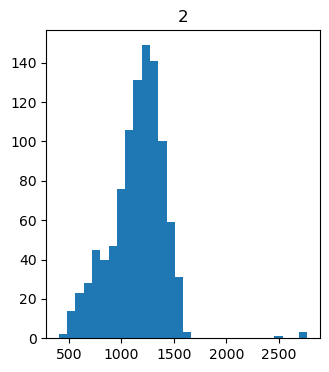

In [3]:
print("Contour lengths:")
for organ, lengths in contour_lengths.items():
    print(f"Organ {organ}: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")

plt.figure(figsize=(12, 4))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(1, 3, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)

/tmp/ipykernel_1562029/3609619862.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


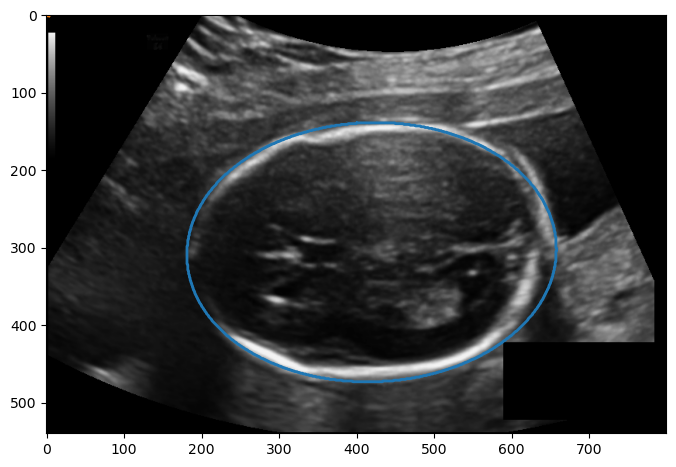

In [4]:
import numpy as np

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[0]
mask_path = Path(CONFIG['output_path']) / 'masks' / image_list[0]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[0]).with_suffix('.json')

image = cv2.imread(str(image_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)

The following code generates the required adjacency matrixes to run the code, from the dictionary of contour lengths.

In [5]:
from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 2 - Contour len mean: 1151.7477477477478 - Atlas contour size: 116
Adjacency matrices sizes: [('full', 116), ('half', 58), ('quarter', 29)]
Downsampling matrices sizes: [('to_half', 58), ('to_quarter', 29)]


Separate splits in training, validation and test

In [3]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
# samples should be taking without putting the same patient in different sets
# the list contains files in the format patient/type/image.png
# so first separate the files by patient

patients = {}
for image in image_list:
    patient = image.split('_')[0]
    if patient not in patients:
        patients[patient] = []
    patients[patient].append(image)

# now we have a dictionary with the patient as key and a list of images as value
# we can now split the patients in training, validation and test
# we will use a 80 - 10 - 10 split

n_patients = len(patients)
n_train = int(0.8 * n_patients)
n_test = int(0.1 * n_patients)
n_val = n_patients - n_train - n_test

random.seed(42)
patients = list(patients.items())
random.shuffle(patients)

train_patients = patients[:n_train]
val_patients = patients[n_train:n_train+n_val]
test_patients = patients[n_train+n_val:]

train_images = []
val_images = []
test_images = []

for patient, images in train_patients:
    train_images.extend(images)
for patient, images in val_patients:
    val_images.extend(images)
for patient, images in test_patients:
    test_images.extend(images)

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))